# Análisis final consolidado

Notebook de cierre del proyecto. Consolida todos los resultados de V1, V2 y V3
en tablas y gráficos definitivos para el informe.

**Secciones:**
1. Tabla maestra de evolución V1 → V2 → V3
2. Gráficos comparativos de ROUGE por versión y modelo
3. Análisis de eficiencia (tiempo de training e inferencia)
4. Resumen de LLM-as-judge
5. Resumen de análisis de errores
6. Conclusiones generales

In [1]:
# Setup
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.data.loader import load_config

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

TABLES_DIR = Path("../results/tables")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Tabla maestra de evolución

In [2]:
# Build the master table from individual CSVs.
# Each row is manually defined to ensure correct labels and ordering.

# V1 baseline
v1 = pd.read_csv(TABLES_DIR / "v1_zero_shot_baseline.csv", index_col=0)

# V2 fine-tuned
v2_t5 = pd.read_csv(TABLES_DIR / "v2_t5_finetuned.csv", index_col=0)
v2_qwen = pd.read_csv(TABLES_DIR / "v2_qwen_lora.csv", index_col=0)

# V3 search results (best configs)
v3_t5 = pd.read_csv(TABLES_DIR / "v3_t5_search.csv")
v3_qwen = pd.read_csv(TABLES_DIR / "v3_qwen_search.csv")

# Get best V3 config for each model
best_t5_v3 = v3_t5.sort_values("rougeL", ascending=False).iloc[0]
best_qwen_v3 = v3_qwen.sort_values("rougeL", ascending=False).iloc[0]

print(f"Best T5 V3: {best_t5_v3['experiment']} (ROUGE-L = {best_t5_v3['rougeL']:.2f})")
print(f"Best Qwen V3: {best_qwen_v3['experiment']} (ROUGE-L = {best_qwen_v3['rougeL']:.2f})")

Best T5 V3: v3_t5_C (ROUGE-L = 23.45)
Best Qwen V3: v3_qwen_A (ROUGE-L = 20.78)


In [3]:
# Consolidated evolution table
master = pd.DataFrame([
    {"Model": "BART-large-cnn (ref)", "Version": "V1 zero-shot",
     "R-1": v1.loc["bart_reference", "rouge1"],
     "R-2": v1.loc["bart_reference", "rouge2"],
     "R-L": v1.loc["bart_reference", "rougeL"],
     "R-Lsum": v1.loc["bart_reference", "rougeLsum"]},
    {"Model": "Pegasus-cnn (ref)", "Version": "V1 zero-shot",
     "R-1": v1.loc["pegasus_reference", "rouge1"],
     "R-2": v1.loc["pegasus_reference", "rouge2"],
     "R-L": v1.loc["pegasus_reference", "rougeL"],
     "R-Lsum": v1.loc["pegasus_reference", "rougeLsum"]},
    {"Model": "Flan-T5-base", "Version": "V1 zero-shot",
     "R-1": v1.loc["t5", "rouge1"],
     "R-2": v1.loc["t5", "rouge2"],
     "R-L": v1.loc["t5", "rougeL"],
     "R-Lsum": v1.loc["t5", "rougeLsum"]},
    {"Model": "Flan-T5-base", "Version": "V2 fine-tuned",
     "R-1": v2_t5.loc["t5_v2", "rouge1"],
     "R-2": v2_t5.loc["t5_v2", "rouge2"],
     "R-L": v2_t5.loc["t5_v2", "rougeL"],
     "R-Lsum": v2_t5.loc["t5_v2", "rougeLsum"]},
    {"Model": "Flan-T5-base", "Version": f"V3 best ({best_t5_v3['experiment']})",
     "R-1": best_t5_v3["rouge1"],
     "R-2": best_t5_v3["rouge2"],
     "R-L": best_t5_v3["rougeL"],
     "R-Lsum": best_t5_v3["rougeLsum"]},
    {"Model": "Qwen3-1.7B", "Version": "V1 zero-shot",
     "R-1": v1.loc["qwen", "rouge1"],
     "R-2": v1.loc["qwen", "rouge2"],
     "R-L": v1.loc["qwen", "rougeL"],
     "R-Lsum": v1.loc["qwen", "rougeLsum"]},
    {"Model": "Qwen3-1.7B", "Version": "V2 LoRA",
     "R-1": v2_qwen.loc["qwen_v2", "rouge1"],
     "R-2": v2_qwen.loc["qwen_v2", "rouge2"],
     "R-L": v2_qwen.loc["qwen_v2", "rougeL"],
     "R-Lsum": v2_qwen.loc["qwen_v2", "rougeLsum"]},
    {"Model": "Qwen3-1.7B", "Version": f"V3 best ({best_qwen_v3['experiment']})",
     "R-1": best_qwen_v3["rouge1"],
     "R-2": best_qwen_v3["rouge2"],
     "R-L": best_qwen_v3["rougeL"],
     "R-Lsum": best_qwen_v3["rougeLsum"]},
])

master.to_csv(TABLES_DIR / "master_evolution.csv", index=False)
master

,Model,Version,R-1,R-2,R-L,R-Lsum
0,BART-large-cnn (ref),V1 zero-shot,35.14,14.54,25.52,29.25
1,Pegasus-cnn (ref),V1 zero-shot,35.07,14.38,25.73,31.76
2,Flan-T5-base,V1 zero-shot,24.96,9.03,19.17,21.64
3,Flan-T5-base,V2 fine-tuned,32.92,12.57,23.25,26.97
4,Flan-T5-base,V3 best (v3_t5_C),33.14,13.00,23.45,27.35
5,Qwen3-1.7B,V1 zero-shot,22.63,5.33,14.84,18.23
6,Qwen3-1.7B,V2 LoRA,30.44,7.78,20.53,27.84
7,Qwen3-1.7B,V3 best (v3_qwen_A),30.41,8.18,20.78,27.75


## 2. Gráficos comparativos

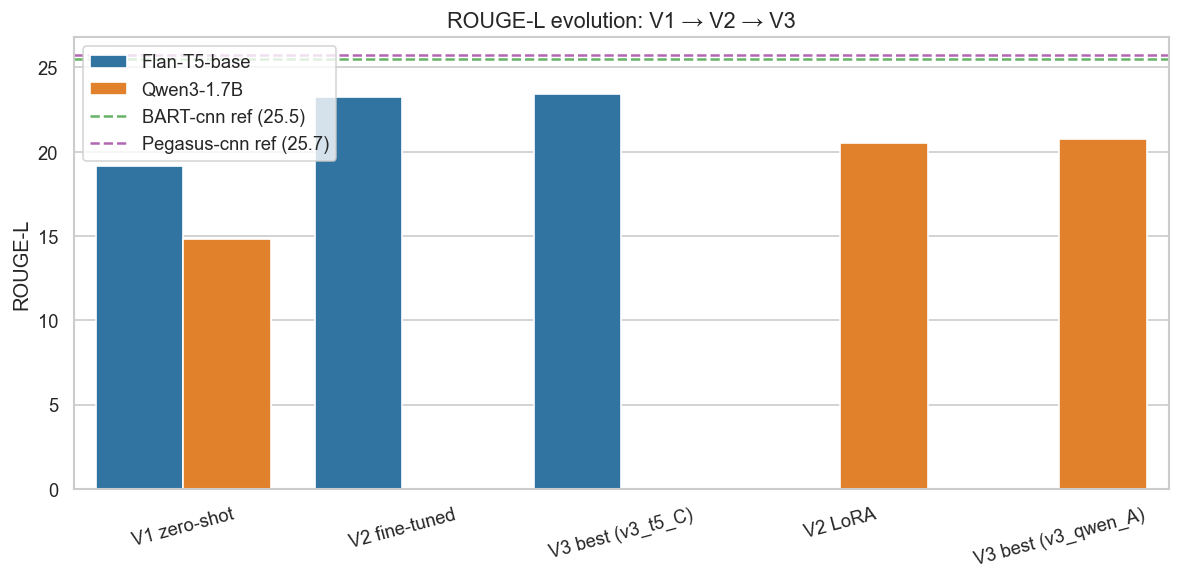

In [4]:
# ROUGE-L evolution by model and version
own_models = master[~master["Model"].str.contains("ref")].copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=own_models, x="Version", y="R-L", hue="Model", ax=ax,
            palette=["tab:blue", "tab:orange"])

# Reference lines for BART and Pegasus
bart_rl = v1.loc["bart_reference", "rougeL"]
peg_rl = v1.loc["pegasus_reference", "rougeL"]
ax.axhline(y=bart_rl, color="green", linestyle="--", alpha=0.6,
           label=f"BART-cnn ref ({bart_rl:.1f})")
ax.axhline(y=peg_rl, color="purple", linestyle="--", alpha=0.6,
           label=f"Pegasus-cnn ref ({peg_rl:.1f})")

ax.set_title("ROUGE-L evolution: V1 → V2 → V3", fontsize=13)
ax.set_ylabel("ROUGE-L")
ax.set_xlabel("")
ax.legend(loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rouge_l_evolution.png", bbox_inches="tight", dpi=150)
plt.show()

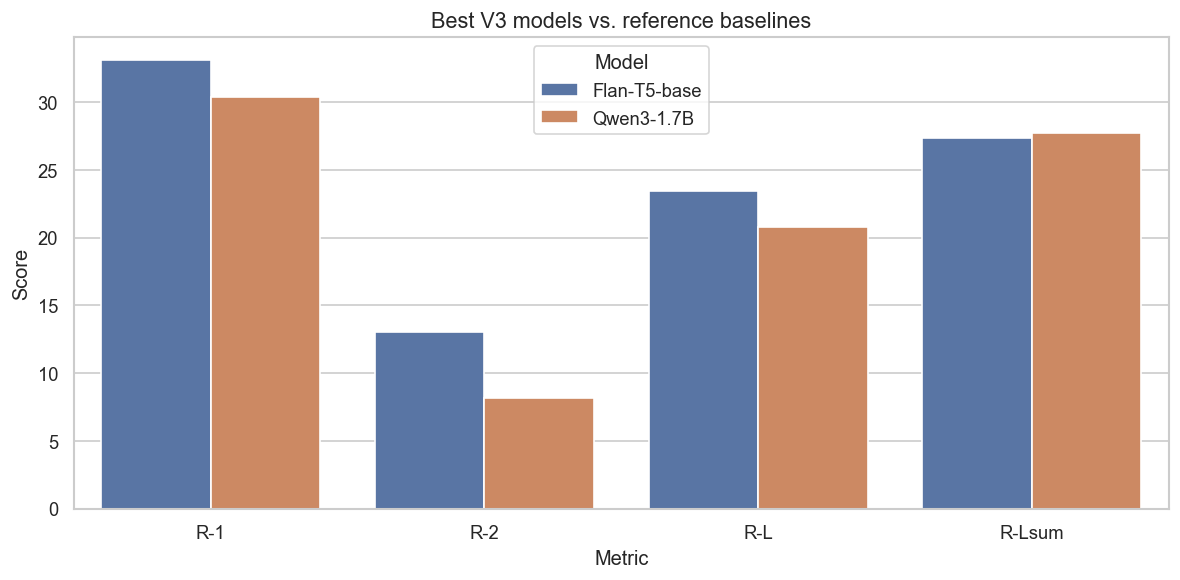

In [5]:
# Four-metric comparison for best V3 models vs references
best_rows = master[
    master["Version"].str.contains("V3 best") | master["Version"].str.contains("ref")
].copy()

metrics = ["R-1", "R-2", "R-L", "R-Lsum"]
best_melted = best_rows.melt(id_vars=["Model", "Version"], value_vars=metrics,
                              var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=best_melted, x="Metric", y="Score", hue="Model", ax=ax)
ax.set_title("Best V3 models vs. reference baselines", fontsize=13)
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_v3_vs_references.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Eficiencia: training e inferencia

In [6]:
# Training efficiency from V3 search results
print("T5 V3 search:")
print(v3_t5[["experiment", "rouge1", "rougeL", "train_minutes", "sec_per_sample"]].to_string(index=False))

print("\nQwen3 V3 search:")
print(v3_qwen[["experiment", "rouge1", "rougeL", "train_minutes", "sec_per_sample"]].to_string(index=False))

# Efficiency ratio
t5_best_rl = best_t5_v3["rougeL"]
qwen_best_rl = best_qwen_v3["rougeL"]
t5_train_min = best_t5_v3["train_minutes"]
qwen_train_min = best_qwen_v3["train_minutes"]

print(f"\nEfficiency comparison (best configs):")
print(f"  T5:    ROUGE-L={t5_best_rl:.2f}, train={t5_train_min:.0f} min")
print(f"  Qwen3: ROUGE-L={qwen_best_rl:.2f}, train={qwen_train_min:.0f} min")
print(f"  ROUGE-L per training hour: T5={t5_best_rl/(t5_train_min/60):.1f}, "
      f"Qwen3={qwen_best_rl/(qwen_train_min/60):.1f}")

T5 V3 search:
experiment  rouge1  rougeL  train_minutes  sec_per_sample
   v3_t5_C   33.14   23.45          755.1            1.29
   v3_t5_A   32.92   23.25          399.5            0.42
   v3_t5_B   32.63   22.74          191.4            1.89

Qwen3 V3 search:
experiment  rouge1  rougeL  train_minutes  sec_per_sample
 v3_qwen_A   30.41   20.78           55.7            1.85
 v3_qwen_C   30.36   20.63          574.8           26.37
 v3_qwen_B   30.68   20.50          112.5            1.90

Efficiency comparison (best configs):
  T5:    ROUGE-L=23.45, train=755 min
  Qwen3: ROUGE-L=20.78, train=56 min
  ROUGE-L per training hour: T5=1.9, Qwen3=22.4


## 4. Resumen de LLM-as-judge

In [7]:
# Load LLM-judge results
judge_path = TABLES_DIR / "llm_judge_results.csv"
if judge_path.exists():
    df_judge = pd.read_csv(judge_path)
    df_judge["error"] = df_judge["error"].fillna("")
    valid = df_judge[df_judge["error"] == ""].copy()
    if len(valid) > 0:
        means = valid.groupby("model")[["coherence", "faithfulness", "fluency"]].mean().round(2)
        print("LLM-as-judge mean scores (1-5):\n")
        print(means.to_string())
    else:
        print("No valid judge evaluations found.")
else:
    print("LLM-judge results not found. Run notebook 07 first.")

LLM-as-judge mean scores (1-5):

              coherence  faithfulness  fluency
model                                         
Flan-T5-base       4.00          4.18     4.18
Qwen3-1.7B         3.46          3.80     3.76


## 5. Resumen de análisis de errores

In [8]:
# Load error analysis results
errors_path = TABLES_DIR / "error_analysis.csv"
if errors_path.exists():
    df_errors = pd.read_csv(errors_path)
    df_errors["error_type"] = df_errors["error_type"].fillna("UNKNOWN")
    real = df_errors[~df_errors["error_type"].isin(["NONE", "PARSE_ERROR", "UNKNOWN"])]
    if len(real) > 0:
        ct = pd.crosstab(real["error_type"], real["model"])
        print("Error counts by model and type:\n")
        print(ct.to_string())
    else:
        print("No real errors detected by the automated judge (all NONE or PARSE_ERROR).")
        print("Distribution:")
        print(df_errors["error_type"].value_counts().to_string())
else:
    print("Error analysis results not found. Run notebook 09 first.")

No real errors detected by the automated judge (all NONE or PARSE_ERROR).
Distribution:
error_type
PARSE_ERROR    64
NONE           36


## Conclusiones generales

### Respuesta a la pregunta central

> *¿Puede un LLM decoder-only moderno (Qwen3-1.7B) adaptado mediante LoRA
> competir con un encoder-decoder diseñado para seq2seq (Flan-T5-base)
> con full fine-tuning, en summarization de noticias?*

**La respuesta es: depende de qué se mida.**

- **En métricas léxicas (ROUGE-1, ROUGE-L):** Flan-T5-base gana. Con 250M
  parámetros y full fine-tuning alcanza 33.14 ROUGE-1, frente a los 30.41 de
  Qwen3 (7x más grande, con LoRA). La arquitectura encoder-decoder sigue
  siendo más eficiente en rendimiento por parámetro para tareas seq2seq
  bien definidas.

- **En estructura narrativa (ROUGE-Lsum):** Qwen3 gana ligeramente (27.75 vs
  27.35). Los resúmenes de Qwen3 están mejor segmentados por frases, con un
  estilo periodístico ("NEW: X . Y . Z .") que ROUGE-Lsum premia.

- **En calidad percibida (LLM-as-judge):** Flan-T5-base gana en las tres
  dimensiones — coherencia (4.00 vs 3.46), fidelidad (4.18 vs 3.80) y fluidez
  (4.18 vs 3.76). Los resúmenes de T5 son más naturales y contienen menos
  alucinaciones.

- **En eficiencia:** Qwen3 con LoRA es 12x más eficiente en training (56 min vs
  755 min) y entrena solo 0.37% de los parámetros. Si el presupuesto de cómputo
  importa, LoRA sobre un LLM generalista es claramente preferible.

### Hallazgos principales

1. **El fine-tuning aporta ~8 puntos de ROUGE-1 en ambas familias** — un salto
   de un tercio sobre el baseline zero-shot, con solo 10-20k muestras de training.

2. **La ventana de contexto es un factor dominante.** T5 trunca el 73% de los
   artículos; Qwen3 solo el 5.6%. Pese a ello, T5 fine-tuneado gana, lo que
   sugiere que su arquitectura encoder-decoder compensa la pérdida de contexto
   con mayor eficiencia de procesamiento de la información disponible.

3. **ROUGE y calidad percibida no correlacionan perfectamente.** Qwen3 gana en
   ROUGE-Lsum pero pierde en las tres dimensiones del LLM-judge. La evaluación
   multi-dimensional es imprescindible para un análisis completo.

4. **La optimización de hiperparámetros aporta mejoras modestas (+0.2 ROUGE-L).**
   El grueso de la ganancia viene del fine-tuning en sí, no de la búsqueda de
   la configuración óptima. Más datos (20k vs 10k) ayudan más que más epochs
   o LR distintos.

5. **LoRA sobre FFN layers no aporta valor en esta tarea.** Triplicar los
   parámetros entrenables incluyendo gate/up/down_proj no mejora ROUGE y
   multiplica el tiempo de training por 10.

### Limitaciones del trabajo

- **Subset de 200 muestras para evaluación** — introduce varianza de ±2-3
  puntos. Una evaluación sobre el test set completo (~11.500) daría números
  más estables.
- **Un solo dataset (CNN/DailyMail)** — no podemos generalizar a otros
  dominios (papers científicos, diálogos, documentos legales).
- **Juez automático de 1.7B** — limitado para detectar errores sutiles.
  Un juez más capaz (GPT-4, humanos) daría evaluaciones cualitativas más
  fiables.
- **Comparación no puramente arquitectónica** — mezclamos el efecto de la
  arquitectura (encoder-decoder vs decoder-only) con el del tamaño de contexto,
  el tamaño del modelo, y la estrategia de fine-tuning (full vs LoRA). Una
  comparación controlada requeriría aislar cada variable.

### Trabajo futuro

- Ampliar evaluación al test set completo (~11.500 muestras)
- Probar Qwen3-4B con QLoRA para evaluar el efecto del tamaño del decoder-only
- Evaluar en un segundo dataset (XSum, ArXiv) para medir generalización
- Incorporar evaluación humana para validar el LLM-judge
- Explorar T5 con contexto extendido (Longformer-Encoder-Decoder) para
  aislar el efecto de la ventana de contexto

### Nota sobre comparabilidad

> *Esta comparación no aísla el impacto de la arquitectura (encoder-decoder
> vs decoder-only) del impacto del tamaño de contexto, el número de
> parámetros, o la estrategia de fine-tuning. Se trata de una comparación
> práctica entre dos modelos representativos de cada familia, tal como están
> disponibles en su forma pre-entrenada estándar. Una comparación puramente
> arquitectónica requeriría controlar cada una de estas variables por
> separado, lo cual queda fuera del alcance de este trabajo.*